<a href="https://colab.research.google.com/github/ashsiendo/DATA-201-Labs/blob/main/Assignments/Week2_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 2 Homework** - Ash Ibasan

EDA focus on the college, auto, and Boston datasets; includes data summaries, visualizations, and understanding relationships between variables.

***Note to self: Comments throughout are used as guides, mainly for Python syntax and reasons why certain steps are used.***

## Setup

*Import libraries necessary for answering homework questions. Datasets will be imported separately.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Q8 - College**

*The `college` dataset contains statistics for 777 US colleges and universities*

## 8a)

Read the `College.csv` dataset into Python and view data

In [3]:
college = pd.read_csv("/content/drive/MyDrive/DATA 201 Fall 2026/Datasets/College.csv")
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


## 8b)

Set the college names as the DataFrame's row index so they are not treated as a variable in the dataset (each row to be identified by its college name)

In [4]:
college2 = pd.read_csv("/content/drive/MyDrive/DATA 201 Fall 2026/Datasets/College.csv",
                       index_col=0) # index_col=0 uses first column (college names) as row index
college2.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [5]:
college3 = college.rename({"Unnamed: 0": "College"}, axis=1) # rename first column
college3 = college3.set_index("College") # set college names as row index
college3.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [6]:
college = college3 # keep modified version as main college DataFrame

## 8c)

Use `describe()` to produce a numerical summary of the variables in the college dataset

In [7]:
college.describe() # gives statistical overview of all quantitative variables

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


## 8d)

Create a scatterplot matrix comparing `Top10perc`, `Apps`, and `Enroll`

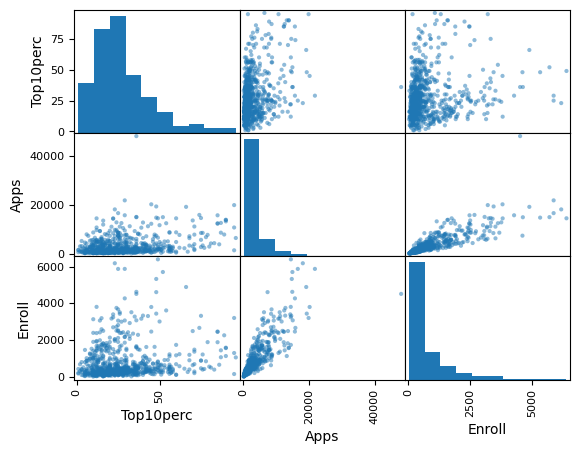

In [8]:
columns = ["Top10perc", "Apps", "Enroll"] # list allows multiple DataFrame columns to be selected at once

pd.plotting.scatter_matrix(college[columns])
plt.show()

## 8e)

Create side-by-side boxplots comparing `Outstate` tuition for private and public colleges

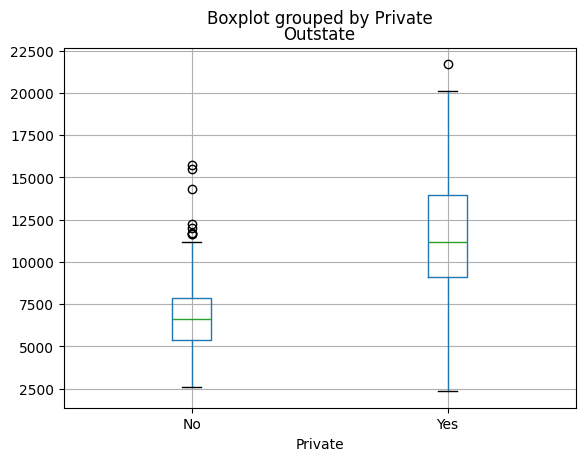

In [9]:
college.boxplot(column="Outstate", by="Private") # by= groups the numerical variable using categories in Private
plt.show()

## 8f)

Create an `Elite` variable by grouping colleges based on whether more than 50% of their students come from the top 10% of their high school classes. Count the elite colleges, then compare `Outstate` tuition between elite and non-elite colleges using side-by-side boxplots

In [10]:
# Top10perc is stored as percentages (1-96), so use 0, 50, 100 instead of 0, 0.5, 1
# pd.cut() bins Top10perc into two groups based on 50% threshold
college["Elite"] = pd.cut(college["Top10perc"],
                          [0, 50, 100],
                          labels=["No", "Yes"])
college["Elite"].value_counts()

,count
Elite,
No,699
Yes,78


*78 colleges are classified as elite.*

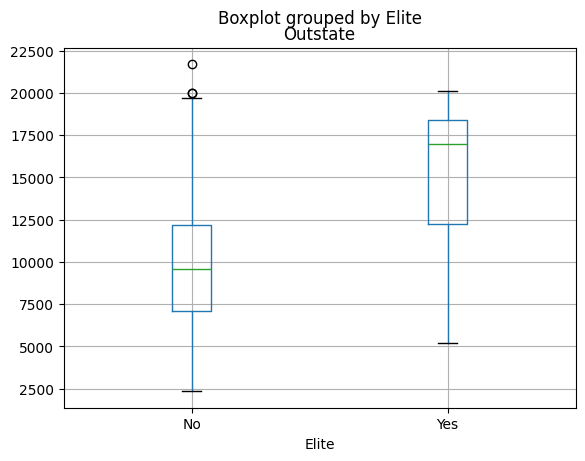

In [11]:
college.boxplot(column="Outstate", by="Elite")
plt.show()

## 8g)

Create histograms for several quantitative variables using different numbers of bins

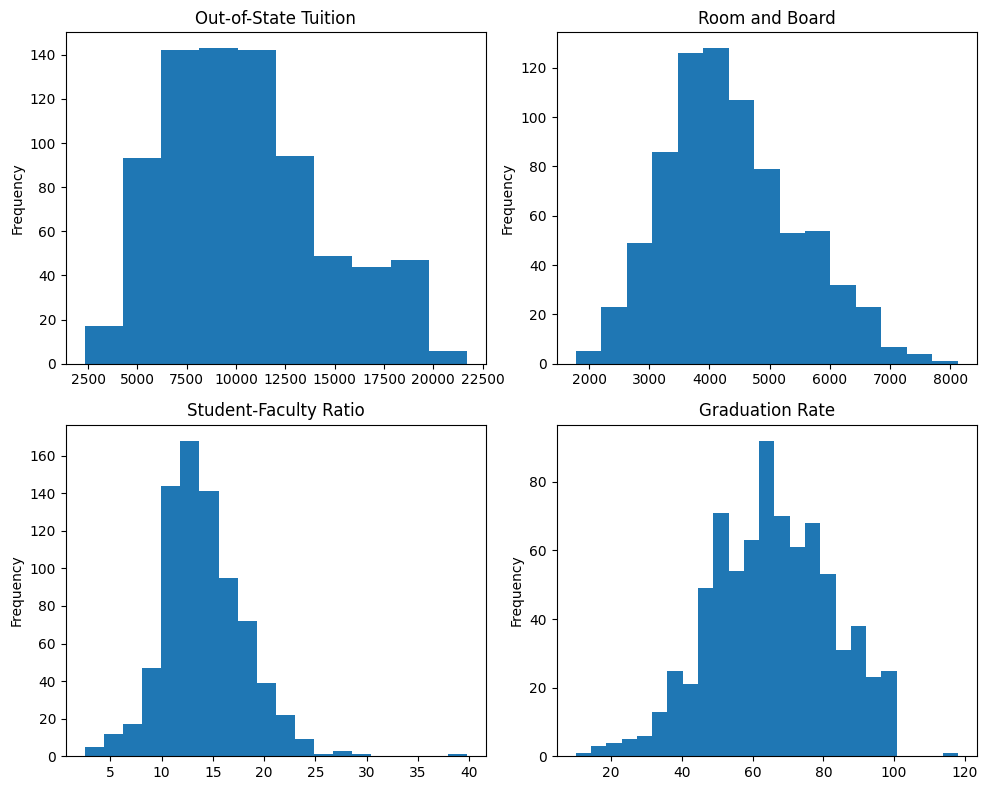

In [12]:
# creates 2x2 grid so four histograms can be displayed together
# figsize=(width, height) sets size of the entire figure (inches)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# ax=[row, column] chooses where each histogram goes in grid
college["Outstate"].plot.hist(bins=10, ax=axes[0, 0])
college["Room.Board"].plot.hist(bins=15, ax=axes[0, 1])
college["S.F.Ratio"].plot.hist(bins=20, ax=axes[1, 0])
college["Grad.Rate"].plot.hist(bins=25, ax=axes[1, 1])

axes[0, 0].set_title("Out-of-State Tuition")
axes[0, 1].set_title("Room and Board")
axes[1, 0].set_title("Student-Faculty Ratio")
axes[1, 1].set_title("Graduation Rate")

plt.tight_layout()
plt.show()

## 8h)

Continue dataset exploration and provide a brief summary of interesting findings

**1) Which college has a graduation rate of over 100%?**

In [13]:
college.loc[college["Grad.Rate"] > 100, "Grad.Rate"]

,Grad.Rate
College,
Cazenovia College,118


*Cazenovia College has a reported 118% graduation rate; above expected maximum of 100%*

**2) Which colleges have the highest out-of-state tuition?**

In [14]:
college["Outstate"].sort_values(ascending=False).head() # .sort_values(ascending=False) sorts values from largest to smallest

,Outstate
College,
Bennington College,21700
Massachusetts Institute of Technology,20100
Gettysburg College,19964
Reed College,19960
Princeton University,19900


*The five colleges with the highest out-of-state tuition are all private colleges*

**3) Student-faculty ratio statistics**

In [15]:
college["S.F.Ratio"].describe()

,S.F.Ratio
count,777.000000
mean,14.089704
std,3.958349
min,2.500000
25%,11.500000
50%,13.600000
75%,16.500000
max,39.800000


*Student-faculty ratios have a median of 13.6 and an average of about 14.1. The middle 50% range from 11.5 to 16.5, though the overall range is much wider: from 2.5 to 39.8*

In [16]:
# highest s-f ratios
college["S.F.Ratio"].sort_values(ascending=False).head()

,S.F.Ratio
College,
Indiana Wesleyan University,39.8
Mesa State College,28.8
Lesley College,27.8
Goldey Beacom College,27.6
Saint Joseph's College,27.2


In [17]:
# lowest s-f ratios
college["S.F.Ratio"].sort_values().head()

,S.F.Ratio
College,
University of Charleston,2.5
Case Western Reserve University,2.9
Johns Hopkins University,3.3
Washington University,3.9
Wake Forest University,4.3


*Student-faculty ratios were sorted from highest to lowest and lowest to highest to see which colleges were at the extremes. Indiana Wesleyan University	was the upper extreme at 39.8, while the University of Charleston was the lower extreme at 2.5*

# **Q9 - Auto**

*The `auto` dataset contains information about different automobiles*

## 9a)

Which predictors are quantitative, and which are qualitative?

In [18]:
auto = pd.read_csv("/content/drive/MyDrive/DATA 201 Fall 2026/Datasets/Auto.csv")
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [19]:
auto.columns # check column names in dataset

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='object')

**Qualitative and Quantitative Predictors**

- Quantitative: `mpg`, `displacement`, `horsepower`, `weight`, `acceleration`
- Qualitative: `cylinders`, `year`, `origin`, `name`

*`cylinders`, `origin`, and `year` may be stored as numbers, but they are treated as categorical variables in the dataset because they represent distinct groups or categories rather than continuous numerical measurements*


9b)

*Find the range of each quantitative predictor using the min and max values*

In [20]:
auto["horsepower"].unique() # check horsepower values

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [21]:
auto["horsepower"] = auto["horsepower"].replace("?", pd.NA) # horsepower contains "?" instead of recognized missing values
auto["horsepower"] = pd.to_numeric(auto["horsepower"])

# find min and max for each quantitative predictor
# print() shows all five ranges in same code cell
print("mpg:", auto["mpg"].min(), "-", auto["mpg"].max())
print("displacement:", auto["displacement"].min(), "-", auto["displacement"].max())
print("horsepower:", auto["horsepower"].min(), "-", auto["horsepower"].max())
print("weight:", auto["weight"].min(), "-", auto["weight"].max())
print("acceleration:", auto["acceleration"].min(), "-", auto["acceleration"].max())

mpg: 9.0 - 46.6
displacement: 68.0 - 455.0
horsepower: 46.0 - 230.0
weight: 1613 - 5140
acceleration: 8.0 - 24.8


## 9c)

*Find the mean and standard deviation of each quantitative predictor*

**Trying two approaches to calculate the same statistics and compare the results:**

In [22]:
# approach 1: calculate mean and std directly for each predictor using print() so all five results can be displayed in same code cell
print("mpg - mean:", auto["mpg"].mean(), "std:", auto["mpg"].std())
print("displacement - mean:", auto["displacement"].mean(), "std:", auto["displacement"].std())
print("horsepower - mean:", auto["horsepower"].mean(), "std:", auto["horsepower"].std())
print("weight - mean:", auto["weight"].mean(), "std:", auto["weight"].std())
print("acceleration - mean:", auto["acceleration"].mean(), "std:", auto["acceleration"].std())

mpg - mean: 23.51586901763224 std: 7.825803928946562
displacement - mean: 193.53274559193954 std: 104.37958329992945
horsepower - mean: 104.46938775510205 std: 38.49115993282855
weight - mean: 2970.2619647355164 std: 847.9041194897246
acceleration - mean: 15.55566750629723 std: 2.7499952929761515


In [23]:
quantitative = ["mpg", "displacement", "horsepower", "weight", "acceleration"] # approach 2: describe() gives same mean and standard deviation along with other summary statistics
auto[quantitative].describe()

,mpg,displacement,horsepower,weight,acceleration
count,397.000000,397.000000,392.000000,397.000000,397.000000
mean,23.515869,193.532746,104.469388,2970.261965,15.555668
std,7.825804,104.379583,38.491160,847.904119,2.749995
min,9.000000,68.000000,46.000000,1613.000000,8.000000
25%,17.500000,104.000000,75.000000,2223.000000,13.800000
50%,23.000000,146.000000,93.500000,2800.000000,15.500000
75%,29.000000,262.000000,126.000000,3609.000000,17.100000
max,46.600000,455.000000,230.000000,5140.000000,24.800000


## 9d)

*Remove the 10th through 85th observations, then find the range, mean, and standard deviation of each quantitative predictor in the remaining data*

In [29]:
auto_reduced = auto.copy() # create copy to remove observations without changing original auto dataset
auto_reduced = auto_reduced.drop(auto_reduced.index[9:85]) # remember Python starts at position 0; [9:85] represents 10th through 85th observations
auto_reduced.shape # check that 76 observations were removed

(321, 9)

***Note to self**: A subset is the standard term for a smaller selection of observations and/or variables from a dataset*

In [31]:
# approach 1: calculate range, mean, and std directly for each quantitative predictor
print("mpg - range:", auto_reduced["mpg"].min(), "-", auto_reduced["mpg"].max(),
      "mean:", auto_reduced["mpg"].mean(), "std:", auto_reduced["mpg"].std())
print("displacement - range:", auto_reduced["displacement"].min(), "-", auto_reduced["displacement"].max(),
      "mean:", auto_reduced["displacement"].mean(), "std:", auto_reduced["displacement"].std())
print("horsepower - range:", auto_reduced["horsepower"].min(), "-", auto_reduced["horsepower"].max(),
      "mean:", auto_reduced["horsepower"].mean(), "std:", auto_reduced["horsepower"].std())
print("weight - range:", auto_reduced["weight"].min(), "-", auto_reduced["weight"].max(),
      "mean:", auto_reduced["weight"].mean(), "std:", auto_reduced["weight"].std())
print("acceleration - range:", auto_reduced["acceleration"].min(), "-", auto_reduced["acceleration"].max(),
      "mean:", auto_reduced["acceleration"].mean(), "std:", auto_reduced["acceleration"].std())

mpg - range: 11.0 - 46.6 mean: 24.438629283489096 std: 7.908184248945195
displacement - range: 68.0 - 455.0 mean: 187.04984423676012 std: 99.63538531961508
horsepower - range: 46.0 - 230.0 mean: 100.95583596214512 std: 35.89556677713123
weight - range: 1649 - 4997 mean: 2933.96261682243 std: 810.6429384125482
acceleration - range: 8.5 - 24.8 mean: 15.723052959501558 std: 2.6805138313971697


In [30]:
auto_reduced[quantitative].describe() # approach 2: describe() gives the min, max, mean, and std in one summary

,mpg,displacement,horsepower,weight,acceleration
count,321.000000,321.000000,317.000000,321.000000,321.000000
mean,24.438629,187.049844,100.955836,2933.962617,15.723053
std,7.908184,99.635385,35.895567,810.642938,2.680514
min,11.000000,68.000000,46.000000,1649.000000,8.500000
25%,18.000000,100.000000,75.000000,2215.000000,14.000000
50%,23.900000,145.000000,90.000000,2795.000000,15.500000
75%,30.700000,250.000000,115.000000,3504.000000,17.300000
max,46.600000,455.000000,230.000000,4997.000000,24.800000


## 9e)

Use visualizations to investigate relationships among the predictors in the full `auto` dataset and comment on any findings

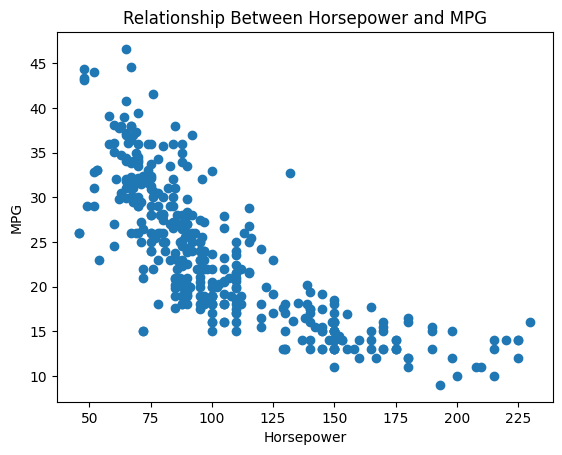

In [33]:
plt.scatter(auto["horsepower"], auto["mpg"])

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Relationship Between Horsepower and MPG")

plt.show()

*A negative relationship is shown between horsepower and MPG. As horsepower increases, MPG generally decreases, so cars with greater horsepower tend to be less fuel-efficient*

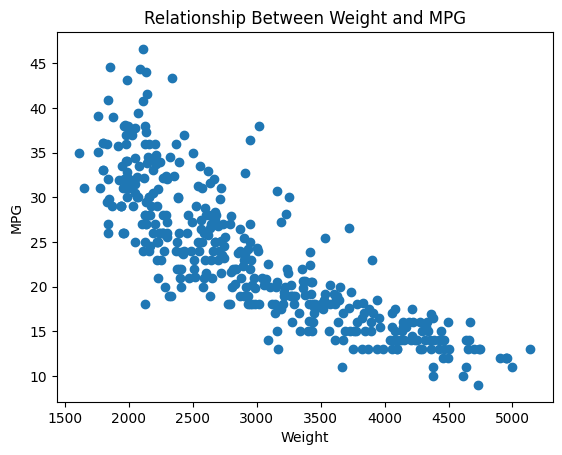

In [34]:
plt.scatter(auto["weight"], auto["mpg"])

plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Relationship Between Weight and MPG")

plt.show()

*Heavier cars tend to be less fuel-efficient (lower MPG), showing a clear negative relationship between vehicle weight and fuel efficiency*

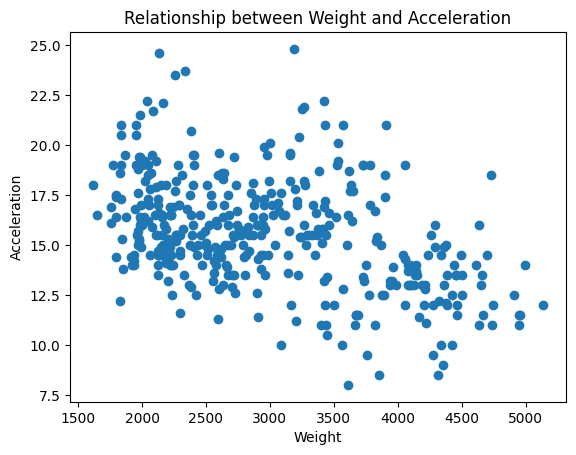

In [35]:
plt.scatter(auto["weight"], auto["acceleration"])

plt.xlabel("Weight")
plt.ylabel("Acceleration")
plt.title("Relationship between Weight and Acceleration")

plt.show()

*The relationship between weight and acceleration time is generally negative, but the pattern is fairly scattered. Heavier cars tend to have shorter acceleration times in this dataset, but there is considerable variation among the observations*

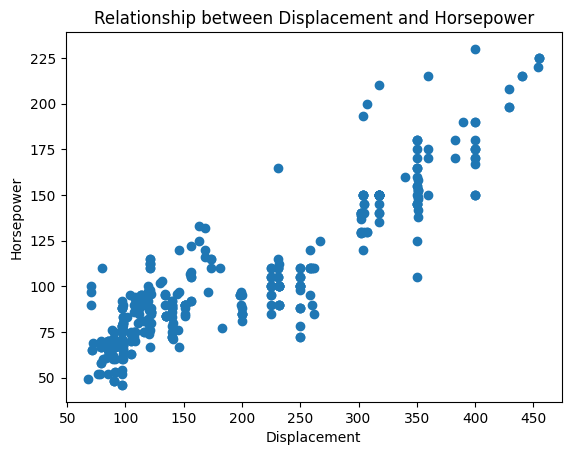

In [37]:
plt.scatter(auto["displacement"], auto["horsepower"])

plt.xlabel("Displacement")
plt.ylabel("Horsepower")
plt.title("Relationship between Displacement and Horsepower")

plt.show()

*Cars with larger engines tend to produce more horsepower, giving displacement and horsepower a clear positive relationship*

***Note to self:** Displacement = engine size/volume (cubic in. in this dataset); larger displacement generally means a larger engine*

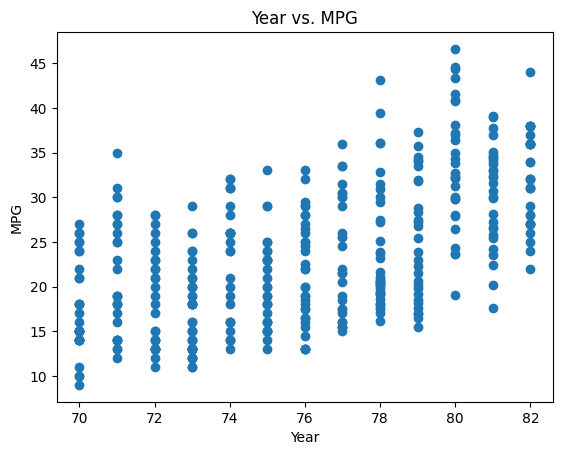

In [38]:
plt.scatter(auto["year"], auto["mpg"])

plt.xlabel("Year")
plt.ylabel("MPG")
plt.title("Relationship Between Year and MPG")

plt.show()

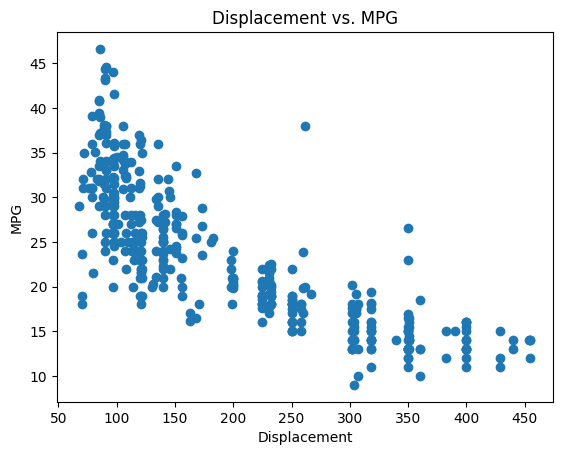

In [39]:
plt.scatter(auto["displacement"], auto["mpg"])

plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.title("Relationship Between Displacement and MPG")

plt.show()

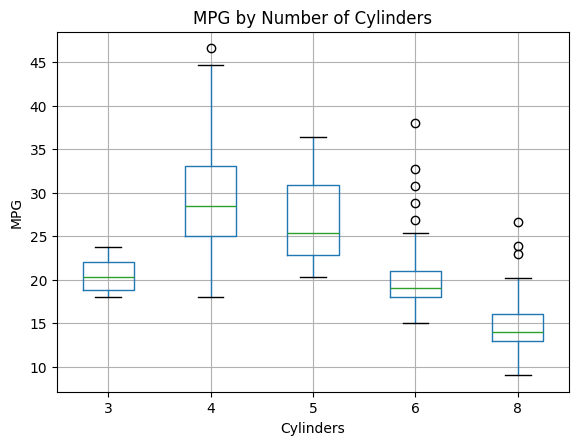

In [40]:
auto.boxplot(column="mpg", by="cylinders")
plt.xlabel("Cylinders")
plt.ylabel("MPG")
plt.title("MPG by Number of Cylinders")
plt.suptitle("")
plt.show()

## 9f)

*Based on the plots, do any of the other variables appear useful for predicting MPG?*